# Lesson 26B: Self-Supervised Contrastive Representation Learning (Practical)

## Introduction

Lesson 26A derived InfoNCE and NT-Xent from first principles, checked every formula numerically, and
ran one honest end-to-end SimCLR pass on MNIST. It measured that the contrastive representation TIES
raw pixels on k-NN accuracy while separating classes far better -- but it never asked the question a
self-supervised method actually exists to answer: **does the representation transfer when only a
HANDFUL of labels are available?** That is what a linear probe measures, and it is what this notebook
adds.

Three representations go into the SAME probe, trained on the SAME small labelled subset, evaluated on
the SAME held-out test set: the from-scratch SimCLR encoder (26A, reused unchanged), PCA (Lesson 5),
and a convolutional autoencoder's bottleneck (Lesson 12B, reused unchanged). Then k-NN and a
t-SNE/UMAP view put all three side by side, three ablations turn 26A's derived claims about
temperature, negatives and augmentation strength into measured curves, and the closing section
connects the whole exercise to Lesson 16's scarce-label setting -- a linear probe on frozen features
IS a light-touch use of a small labelled set, the same resource Lesson 16 is built around.

## Table of Contents

1. [Required Libraries](#required-libraries)
2. [SimCLR Pre-training and a Linear Probe](#simclr-probe)
3. [The Comparison That Matters: Contrastive vs PCA vs Autoencoder](#three-way)
4. [k-NN and a Side-by-Side 2D View](#knn-viz)
5. [Ablations: Temperature, Negatives, Augmentation Strength](#ablations)
6. [Guidance: When Self-Supervised Pretraining Pays Off](#guidance)
7. [Conclusion](#conclusion)

<a name="required-libraries"></a>
## Required Libraries

In [1]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print(f"PyTorch {torch.__version__}, UMAP available: {HAS_UMAP}")
print("Data: the same cached MNIST 26A used -- nothing downloaded.")

PyTorch 2.13.0+cu130, UMAP available: True
Data: the same cached MNIST 26A used -- nothing downloaded.


<a name="simclr-probe"></a>
## SimCLR Pre-training and a Linear Probe

**Same corpus as 26A, same seed, same 6,000 unlabelled images** -- reused verbatim, not re-derived, so
any difference from here on is about the evaluation, not the data. The encoder, augmentation stack and
NT-Xent loss below are copied from 26A unchanged (see 26A Sections 6 and 8 for their derivation and
from-scratch validation); this notebook trains them once more only because a fresh Python session has
no access to 26A's in-memory model.

In [2]:
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
N_IMAGES = 6000
X_img = train_dataset.data[:N_IMAGES].float().unsqueeze(1) / 255.0
y_true = train_dataset.targets[:N_IMAGES]
flat = X_img.reshape(N_IMAGES, -1)
print(f"Loaded {X_img.shape[0]} MNIST images {tuple(X_img.shape[1:])}, matching 26A's corpus exactly.")

# ---- Reused from 26A Section 8 (augmentations), unchanged ----
def _affine_apply(x, theta):
    grid = F.affine_grid(theta, x.shape, align_corners=False)
    return F.grid_sample(x, grid, align_corners=False, padding_mode='zeros')


def rand_crop_resize(x, gen, area_min=0.7, area_max=1.0):
    b = x.shape[0]
    s = (torch.rand(b, generator=gen) * (area_max - area_min) + area_min).sqrt()
    tx = (1 - s) * (torch.rand(b, generator=gen) * 2 - 1)
    ty = (1 - s) * (torch.rand(b, generator=gen) * 2 - 1)
    th = torch.zeros(b, 2, 3)
    th[:, 0, 0] = s; th[:, 1, 1] = s; th[:, 0, 2] = tx; th[:, 1, 2] = ty
    return _affine_apply(x, th)


def rand_rotate(x, gen, max_deg=15.0):
    b = x.shape[0]
    a = (torch.rand(b, generator=gen) * 2 - 1) * math.radians(max_deg)
    th = torch.zeros(b, 2, 3)
    th[:, 0, 0] = torch.cos(a); th[:, 0, 1] = -torch.sin(a)
    th[:, 1, 0] = torch.sin(a); th[:, 1, 1] = torch.cos(a)
    return _affine_apply(x, th)


def add_noise(x, gen, sigma=0.10):
    return (x + torch.randn(x.shape, generator=gen) * sigma).clamp(0, 1)


def simclr_view(x, gen, crop_min=0.7, deg=15.0, sigma=0.10):
    return add_noise(rand_rotate(rand_crop_resize(x, gen, crop_min, 1.0), gen, deg), gen, sigma)


# ---- Reused from 26A Section 6 (SimCLRNet and NT-Xent), unchanged ----
class SimCLRNet(nn.Module):
    'Small CNN encoder (kept) + MLP projection head (discarded after training).'

    def __init__(self, rep_dim=64, proj_dim=32):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, rep_dim), nn.ReLU(),
        )
        self.head = nn.Sequential(nn.Linear(rep_dim, rep_dim), nn.ReLU(), nn.Linear(rep_dim, proj_dim))

    def forward(self, x):
        h = self.backbone(x)
        return h, self.head(h)


def masked_similarity(z, tau):
    n2 = z.shape[0]
    z = F.normalize(z, dim=1)
    sim = (z @ z.t()) / tau
    return sim.masked_fill(torch.eye(n2, dtype=torch.bool, device=z.device), float('-inf'))


def nt_xent(z, tau):
    sim = masked_similarity(z, tau)
    pos_idx = torch.arange(sim.shape[0], device=z.device) ^ 1
    return F.cross_entropy(sim, pos_idx)


def train_simclr(rep_dim=64, epochs=60, batch=256, tau=0.5, lr=3e-3, crop_min=0.7, deg=15.0, sigma=0.10, seed=SEED):
    'One self-contained training run -- used for the main model AND every ablation below.'
    torch.manual_seed(seed)
    model = SimCLRNet(rep_dim=rep_dim)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    n_steps = epochs * (N_IMAGES // batch)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(n_steps, 1))
    gen = torch.Generator().manual_seed(seed)
    losses = []
    t0 = time.time()
    for _ in range(epochs):
        perm = torch.randperm(N_IMAGES, generator=gen)
        running, seen = 0.0, 0
        for start in range(0, N_IMAGES - batch + 1, batch):
            xb = X_img[perm[start:start + batch]]
            _, z1 = model(simclr_view(xb, gen, crop_min, deg, sigma))
            _, z2 = model(simclr_view(xb, gen, crop_min, deg, sigma))
            z = torch.stack([z1, z2], dim=1).reshape(2 * len(xb), -1)
            loss = nt_xent(z, tau)
            opt.zero_grad(); loss.backward(); opt.step(); sched.step()
            running += loss.item() * len(xb); seen += len(xb)
        losses.append(running / seen)
    with torch.no_grad():
        H, _ = model(X_img)
    return model, H.numpy(), losses, time.time() - t0


t0 = time.time()
simclr_model, H_simclr, simclr_losses, simclr_train_s = train_simclr()
print(f"SimCLR: {len(simclr_losses)} epochs, {simclr_train_s:.1f}s CPU, "
      f"loss {simclr_losses[0]:.3f} -> {simclr_losses[-1]:.3f} (chance {math.log(511):.3f}).")

# ---- The linear probe: frozen features, a SMALL labelled subset, sklearn LogisticRegression ----
N_LABELLED = 300
rng_probe = np.random.default_rng(SEED)
labelled_idx = rng_probe.choice(N_IMAGES, N_LABELLED, replace=False)
y_np = y_true.numpy()


def linear_probe(features, idx=labelled_idx, y=y_np, test_size=0.5, seed=SEED):
    'Standardise, split the SMALL labelled subset, fit/report a plain LogisticRegression probe.'
    X_sub, y_sub = features[idx], y[idx]
    X_tr, X_te, y_tr, y_te = train_test_split(X_sub, y_sub, test_size=test_size,
                                               random_state=seed, stratify=y_sub)
    scaler = StandardScaler().fit(X_tr)
    clf = LogisticRegression(max_iter=2000, random_state=seed)
    clf.fit(scaler.transform(X_tr), y_tr)
    return clf.score(scaler.transform(X_te), y_te), len(y_tr), len(y_te)


acc_simclr, n_tr, n_te = linear_probe(H_simclr)
print(f"\nLinear probe on {H_simclr.shape[1]}-d SimCLR features, trained on {n_tr} labels "
      f"(out of {N_IMAGES} images), tested on {n_te} held-out labels: {acc_simclr:.1%} accuracy.")
print(f"({N_LABELLED} of {N_IMAGES} images ({N_LABELLED / N_IMAGES:.1%}) ever had a label touched "
      f"anywhere in this cell -- the other {N_IMAGES - N_LABELLED} trained only the encoder above.)")

Loaded 6000 MNIST images (1, 28, 28), matching 26A's corpus exactly.


SimCLR: 60 epochs, 153.5s CPU, loss 5.489 -> 4.414 (chance 6.236).

Linear probe on 64-d SimCLR features, trained on 150 labels (out of 6000 images), tested on 150 held-out labels: 92.7% accuracy.
(300 of 6000 images (5.0%) ever had a label touched anywhere in this cell -- the other 5700 trained only the encoder above.)


<a name="three-way"></a>
## The Comparison That Matters: Contrastive vs PCA vs Autoencoder

Three feature sets, the identical probe protocol (same 300 labelled images, same 50/50
split, same `LogisticRegression`, same random seed): SimCLR's 64-d representation from above, PCA
(Lesson 5) fit on the raw pixels, and a convolutional autoencoder's bottleneck (Lesson 12B's
`ConvAutoencoder`, reused unchanged) trained on the SAME 6,000 unlabelled images. Dimensionality is
reported honestly rather than matched -- the three methods do not have a natural common dimension, and
forcing one would hide exactly the trade-off worth seeing.

PCA: 64 components explain 86.7% of pixel variance.


ConvAutoencoder: 30 epochs, 10.1s CPU, MSE 0.2242 -> 0.0009, bottleneck dim 1568 (32 channels x 7 x 7, unpooled -- Lesson 12B's own encoder output, not re-designed for this probe).



Linear probe accuracy, 300 labels (150 train / 150 test), identical protocol:
  SimCLR                  64-d   92.7%
  PCA                     64-d   78.0%
  ConvAE bottleneck     1568-d   83.3%

SimCLR leads at 92.7%, 9.3% clear of the runner-up (ConvAE bottleneck, 83.3%).
With only 300 labels, this probe is exactly Lesson 16's scarce-label regime -- see the Guidance section below for what that implies about which representation to pretrain.


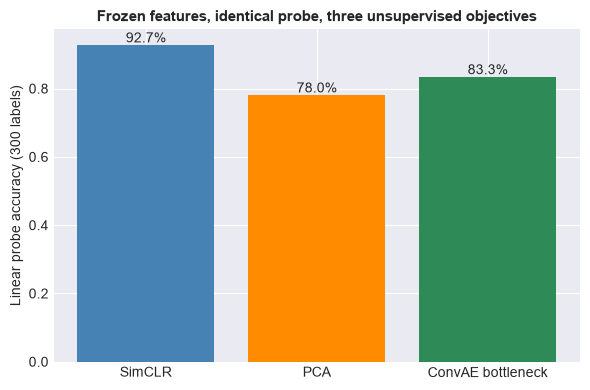

In [3]:
# ---- PCA (Lesson 5), fit on the raw pixels of the SAME 6,000 images ----
pca = PCA(n_components=64, random_state=SEED)
H_pca = pca.fit_transform(flat.numpy())
pca_var = pca.explained_variance_ratio_.sum()
print(f"PCA: 64 components explain {pca_var:.1%} of pixel variance.")

# ---- Convolutional autoencoder (Lesson 12B's ConvAutoencoder, reused unchanged) ----
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def bottleneck(self, x):
        return self.encoder(x).flatten(1)


torch.manual_seed(SEED)
ae = ConvAutoencoder()
opt_ae = torch.optim.Adam(ae.parameters(), lr=1e-3)
gen_ae = torch.Generator().manual_seed(SEED)
AE_EPOCHS, AE_BATCH = 30, 128
t0 = time.time()
ae_losses = []
for _ in range(AE_EPOCHS):
    perm = torch.randperm(N_IMAGES, generator=gen_ae)
    running, seen = 0.0, 0
    for start in range(0, N_IMAGES - AE_BATCH + 1, AE_BATCH):
        xb = X_img[perm[start:start + AE_BATCH]]
        recon = ae(xb)
        loss = F.mse_loss(recon, xb)
        opt_ae.zero_grad(); loss.backward(); opt_ae.step()
        running += loss.item() * len(xb); seen += len(xb)
    ae_losses.append(running / seen)
ae_train_s = time.time() - t0
with torch.no_grad():
    H_ae = ae.bottleneck(X_img).numpy()
print(f"ConvAutoencoder: {AE_EPOCHS} epochs, {ae_train_s:.1f}s CPU, "
      f"MSE {ae_losses[0]:.4f} -> {ae_losses[-1]:.4f}, bottleneck dim {H_ae.shape[1]} "
      f"(32 channels x 7 x 7, unpooled -- Lesson 12B's own encoder output, not re-designed for this probe).")

# ---- The SAME probe protocol on all three ----
feature_sets = [('SimCLR', H_simclr), ('PCA', H_pca), ('ConvAE bottleneck', H_ae)]
probe_results = {}
for name, H in feature_sets:
    acc, n_tr, n_te = linear_probe(H)
    probe_results[name] = acc
print(f"\nLinear probe accuracy, {N_LABELLED} labels ({n_tr} train / {n_te} test), identical protocol:")
for name, H in feature_sets:
    print(f"  {name:<20} {H.shape[1]:>5}-d   {probe_results[name]:.1%}")

ranked = sorted(probe_results.items(), key=lambda kv: -kv[1])
TOL_PROBE = 0.02
best_name, best_acc = ranked[0]
ties = [n for n, a in ranked if best_acc - a <= TOL_PROBE]
if len(ties) > 1:
    print(f"\n{' and '.join(ties)} are statistically tied for best (within {TOL_PROBE:.0%}) at "
          f"{', '.join(f'{probe_results[n]:.1%}' for n in ties)}.")
else:
    runner_up_acc = ranked[1][1]
    print(f"\n{best_name} leads at {best_acc:.1%}, {best_acc - runner_up_acc:.1%} clear of the runner-up "
          f"({ranked[1][0]}, {runner_up_acc:.1%}).")
print(f"With only {N_LABELLED} labels, this probe is exactly Lesson 16's scarce-label regime -- "
      f"see the Guidance section below for what that implies about which representation to pretrain.")

fig, ax = plt.subplots(figsize=(6, 4))
names = [n for n, _ in feature_sets]
ax.bar(names, [probe_results[n] for n in names], color=['steelblue', 'darkorange', 'seagreen'])
for i, n in enumerate(names):
    ax.text(i, probe_results[n], f'{probe_results[n]:.1%}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel(f'Linear probe accuracy ({N_LABELLED} labels)')
ax.set_title('Frozen features, identical probe, three unsupervised objectives', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

<a name="knn-viz"></a>
## k-NN and a Side-by-Side 2D View

A second, complementary diagnostic that (unlike the probe above) uses every label rather than a
scarce 300: 5-NN cross-validated accuracy on each representation, plus a t-SNE map of the
three side by side. Lesson 6A derived t-SNE and then spent a section on its own artifacts; that
caveat is not abandoned here just because the plot is convenient -- **cluster SIZE and inter-cluster
DISTANCE in a t-SNE map are not meaningful**, only which points a cluster contains. UMAP is shown as
well where available, as an independent nonlinear-projection cross-check on the same conclusion,
never as a replacement for the labelled probe above.

5-NN accuracy (3-fold CV, ALL 6,000 labels -- not the scarce-label regime above):
  SimCLR               93.0%
  PCA                  93.6%
  ConvAE bottleneck    92.9%


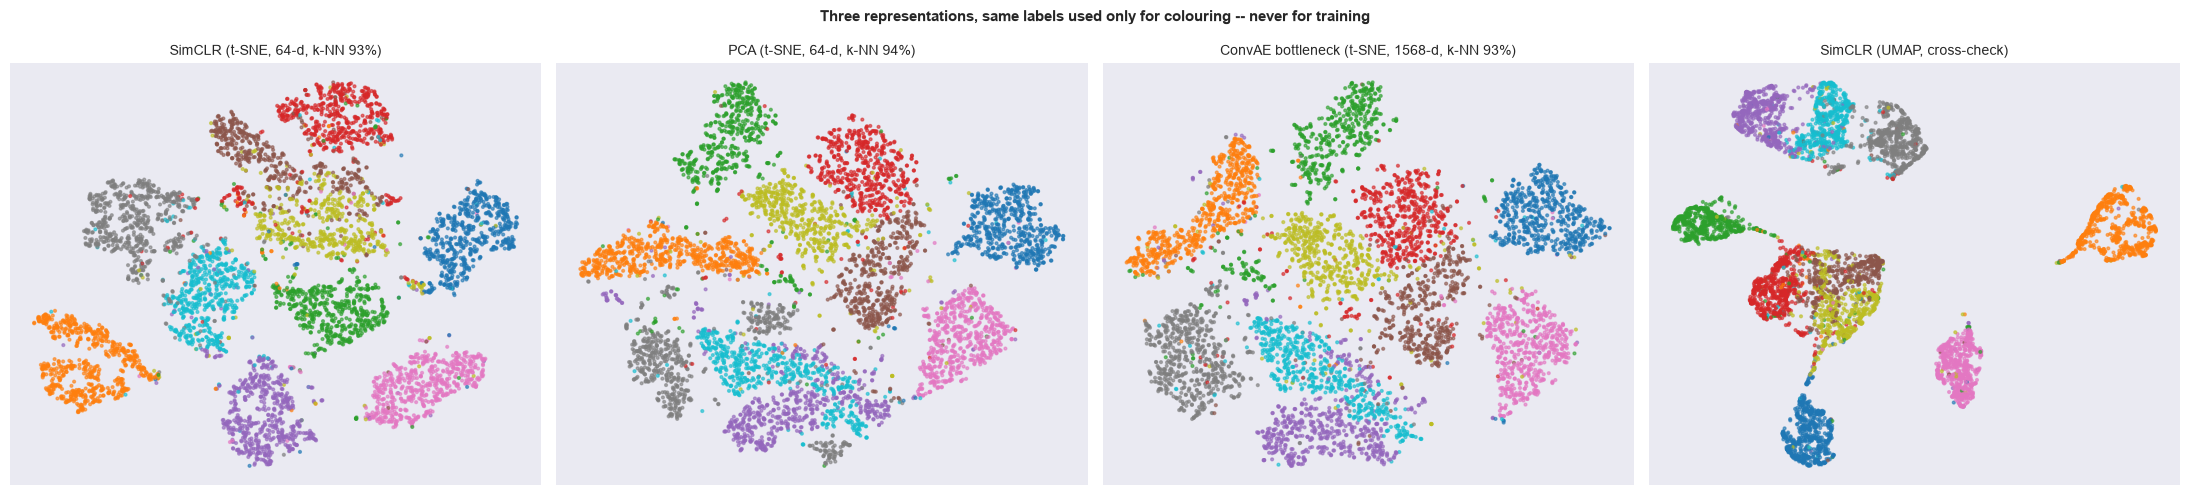


Reminder from Lesson 6A: cluster SIZE and the DISTANCE between clusters in these maps are algorithm artifacts, not measurements. Only cluster MEMBERSHIP (which points group together) is informative -- the k-NN and probe numbers above are the trustworthy quantities.


In [4]:
knn_acc = {name: cross_val_score(KNeighborsClassifier(5), H, y_np, cv=3).mean()
           for name, H in feature_sets}
print("5-NN accuracy (3-fold CV, ALL 6,000 labels -- not the scarce-label regime above):")
for name, _ in feature_sets:
    print(f"  {name:<20} {knn_acc[name]:.1%}")

fig, axes = plt.subplots(1, len(feature_sets) + (1 if HAS_UMAP else 0),
                          figsize=(5.5 * (len(feature_sets) + (1 if HAS_UMAP else 0)), 5))
for ax, (name, H) in zip(axes, feature_sets):
    coords = TSNE(n_components=2, perplexity=30, random_state=SEED).fit_transform(H)
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=y_np, cmap='tab10', s=4, alpha=0.6)
    ax.set_title(f"{name} (t-SNE, {H.shape[1]}-d, k-NN {knn_acc[name]:.0%})", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
if HAS_UMAP:
    reducer = umap.UMAP(random_state=SEED)
    coords_u = reducer.fit_transform(H_simclr)
    axes[-1].scatter(coords_u[:, 0], coords_u[:, 1], c=y_np, cmap='tab10', s=4, alpha=0.6)
    axes[-1].set_title(f"SimCLR (UMAP, cross-check)", fontsize=10)
    axes[-1].set_xticks([]); axes[-1].set_yticks([])
plt.suptitle('Three representations, same labels used only for colouring -- never for training',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()
print("\nReminder from Lesson 6A: cluster SIZE and the DISTANCE between clusters in these maps are "
      "algorithm artifacts, not measurements. Only cluster MEMBERSHIP (which points group together) "
      "is informative -- the k-NN and probe numbers above are the trustworthy quantities.")

<a name="ablations"></a>
## Ablations: Temperature, Negatives, Augmentation Strength

26A derived, from first principles, that temperature sets the critic's dynamic range and that
$\log M$ caps the certified mutual information. Both are properties of the LOSS. This section asks
the practical question instead: does either one move DOWNSTREAM PROBE ACCURACY on this corpus, and
does augmentation strength matter at all? Each sweep trains several short SimCLR runs (fewer epochs
than the main run above, to stay CPU-bounded) and re-uses the identical linear-probe protocol.

  tau=0.1  probe 88.0%  final NT-Xent 1.745  (144.8s)


  tau=0.5  probe 85.3%  final NT-Xent 4.681  (142.7s)


  tau=1.0  probe 80.0%  final NT-Xent 5.411  (38.4s)
Temperature sweep: 326.1s total.


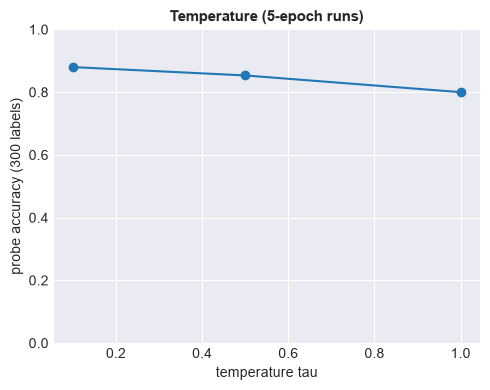

In [5]:
ABL_EPOCHS = 5   # much shorter than the main run's 60 -- each sweep point retrains from scratch

def probe_after_training(**kwargs):
    _, H, losses, secs = train_simclr(epochs=ABL_EPOCHS, **kwargs)
    acc, _, _ = linear_probe(H)
    return acc, losses[-1], secs

# ---- (a) Temperature ----
t_start = time.time()
taus = [0.1, 0.5, 1.0]
tau_acc = {}
for tau in taus:
    acc, final_loss, secs = probe_after_training(tau=tau)
    tau_acc[tau] = acc
    print(f"  tau={tau:<4} probe {acc:.1%}  final NT-Xent {final_loss:.3f}  ({secs:.1f}s)")
print(f"Temperature sweep: {time.time() - t_start:.1f}s total.")

plt.figure(figsize=(5, 4))
plt.plot(list(tau_acc.keys()), list(tau_acc.values()), marker='o')
plt.xlabel('temperature tau'); plt.ylabel(f'probe accuracy ({N_LABELLED} labels)')
plt.title(f'Temperature ({ABL_EPOCHS}-epoch runs)', fontsize=11, fontweight='bold')
plt.ylim(0, 1); plt.tight_layout(); plt.show()

  batch=64   (2N-1=127 ) probe 89.3%  final NT-Xent 3.185  (22.6s)


  batch=128  (2N-1=255 ) probe 88.7%  final NT-Xent 3.911  (16.3s)


  batch=256  (2N-1=511 ) probe 85.3%  final NT-Xent 4.681  (8.9s)
Batch-size sweep: 47.8s total.
Caveat worth stating plainly: at a FIXED epoch count, a smaller batch means MORE optimiser steps per epoch (batch=64: 93 steps, batch=128: 46 steps, batch=256: 23 steps), a 4x spread between the smallest and largest batch here. This ablation cannot cleanly separate fewer negatives from more gradient updates as the cause of any accuracy difference below -- a clean negatives-only comparison would need to hold TOTAL gradient steps fixed across batch sizes, which this sweep does not do.


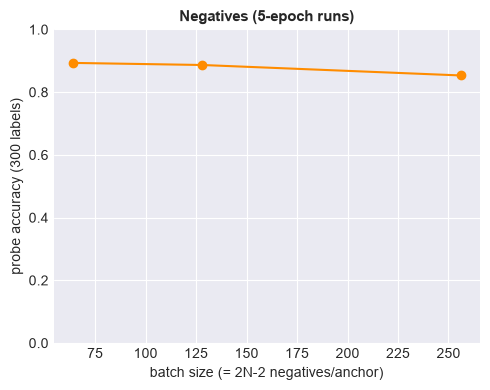

In [6]:
# ---- (b) Batch size (= number of negatives, 2*batch - 2 per anchor) ----
t_start = time.time()
batches = [64, 128, 256]
batch_acc = {}
for b in batches:
    acc, final_loss, secs = probe_after_training(batch=b)
    batch_acc[b] = acc
    print(f"  batch={b:<4} (2N-1={2*b-1:<4}) probe {acc:.1%}  final NT-Xent {final_loss:.3f}  ({secs:.1f}s)")
print(f"Batch-size sweep: {time.time() - t_start:.1f}s total.")

steps_per_epoch = {b: N_IMAGES // b for b in batches}
step_desc = ', '.join(f'batch={b}: {s} steps' for b, s in steps_per_epoch.items())
step_ratio = max(steps_per_epoch.values()) / min(steps_per_epoch.values())
print(f"Caveat worth stating plainly: at a FIXED epoch count, a smaller batch means MORE optimiser "
      f"steps per epoch ({step_desc}), a {step_ratio:.0f}x spread between the smallest and largest "
      f"batch here. This ablation cannot cleanly separate fewer negatives from more gradient updates "
      f"as the cause of any accuracy difference below -- a clean negatives-only comparison would need "
      f"to hold TOTAL gradient steps fixed across batch sizes, which this sweep does not do.")

plt.figure(figsize=(5, 4))
plt.plot(list(batch_acc.keys()), list(batch_acc.values()), marker='o', color='darkorange')
plt.xlabel('batch size (= 2N-2 negatives/anchor)'); plt.ylabel(f'probe accuracy ({N_LABELLED} labels)')
plt.title(f'Negatives ({ABL_EPOCHS}-epoch runs)', fontsize=11, fontweight='bold')
plt.ylim(0, 1); plt.tight_layout(); plt.show()

  weak           probe 77.3%  final NT-Xent 4.509  (8.7s)


  default (26A)  probe 85.3%  final NT-Xent 4.681  (16.6s)


  strong         probe 76.7%  final NT-Xent 5.072  (172.4s)
Augmentation-strength sweep: 197.9s total.


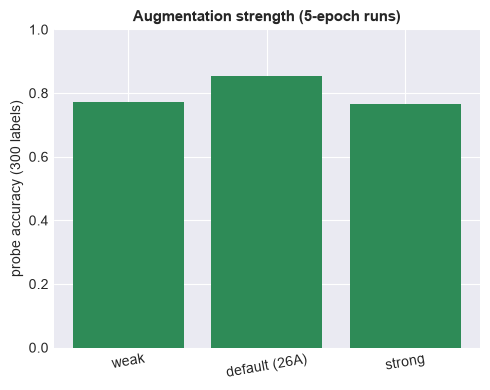


Ranges over 5-epoch runs (all much shorter than the main 60-epoch model, so read as which lever matters, not as absolute accuracy levels):
  temperature            8.0%  (best tau=0.1)
  batch size / negatives 4.0%  (best batch=64)
  augmentation strength  8.7%  (best='default (26A)')

On this corpus and at this 5-epoch training budget, temperature and augmentation strength are statistically tied for widest range (8.0%, 8.7%) -- with only 150 test examples per point, a 1.3% gap is within 2 flipped example(s) of noise, so this ablation cannot actually rank these two levers against each other, only against the clearly narrower one.


In [7]:
# ---- (c) Augmentation strength: weak -> SimCLR default (26A) -> aggressive ----
t_start = time.time()
aug_strengths = {
    'weak':  dict(crop_min=0.9, deg=5.0,  sigma=0.02),
    'default (26A)': dict(crop_min=0.7, deg=15.0, sigma=0.10),
    'strong': dict(crop_min=0.4, deg=30.0, sigma=0.25),
}
aug_acc = {}
for name, kw in aug_strengths.items():
    acc, final_loss, secs = probe_after_training(**kw)
    aug_acc[name] = acc
    print(f"  {name:<14} probe {acc:.1%}  final NT-Xent {final_loss:.3f}  ({secs:.1f}s)")
print(f"Augmentation-strength sweep: {time.time() - t_start:.1f}s total.")

plt.figure(figsize=(5, 4))
plt.bar(list(aug_acc.keys()), list(aug_acc.values()), color='seagreen')
plt.ylabel(f'probe accuracy ({N_LABELLED} labels)')
plt.title(f'Augmentation strength ({ABL_EPOCHS}-epoch runs)', fontsize=11, fontweight='bold')
plt.xticks(rotation=10); plt.ylim(0, 1); plt.tight_layout(); plt.show()

# ---- Summary across all three axes ----
best_tau = max(tau_acc, key=tau_acc.get); worst_tau = min(tau_acc, key=tau_acc.get)
tau_range = tau_acc[best_tau] - tau_acc[worst_tau]
best_batch = max(batch_acc, key=batch_acc.get); worst_batch = min(batch_acc, key=batch_acc.get)
batch_range = batch_acc[best_batch] - batch_acc[worst_batch]
best_aug = max(aug_acc, key=aug_acc.get); worst_aug = min(aug_acc, key=aug_acc.get)
aug_range = aug_acc[best_aug] - aug_acc[worst_aug]
print(f"\nRanges over {ABL_EPOCHS}-epoch runs (all much shorter than the main {len(simclr_losses)}-epoch model, "
      f"so read as which lever matters, not as absolute accuracy levels):")
print(f"  temperature            {tau_range:.1%}  (best tau={best_tau})")
print(f"  batch size / negatives {batch_range:.1%}  (best batch={best_batch})")
print(f"  augmentation strength  {aug_range:.1%}  (best='{best_aug}')")
levers = [('temperature', tau_range), ('batch size', batch_range), ('augmentation strength', aug_range)]
widest = max(levers, key=lambda kv: kv[1])
n_test_ablation = 150   # each ablation point's probe test split (see linear_probe's default test_size)
TOL_LEVER = 2 / n_test_ablation   # ~2 flipped test examples' worth -- below this, call it a tie
ties = [name for name, r in levers if widest[1] - r <= TOL_LEVER]
if len(ties) > 1:
    print(f"\nOn this corpus and at this {ABL_EPOCHS}-epoch training budget, {' and '.join(ties)} are "
          f"statistically tied for widest range ({', '.join(f'{r:.1%}' for _, r in levers if _ in ties)}) -- "
          f"with only {n_test_ablation} test examples per point, a {TOL_LEVER:.1%} gap is within "
          f"{int(round(TOL_LEVER * n_test_ablation))} flipped example(s) of noise, so this ablation cannot "
          f"actually rank these two levers against each other, only against the clearly narrower one.")
else:
    print(f"\nOn this corpus and at this {ABL_EPOCHS}-epoch training budget, {widest[0]} moved probe accuracy "
          f"the most ({widest[1]:.1%} range) of the three levers swept -- read this as which lever to tune "
          f"FIRST here, not as a universal ranking that would hold at a different corpus or training budget.")

<a name="guidance"></a>
## Guidance: When Self-Supervised Pretraining Pays Off

- **Match the augmentation to an invariance the downstream task actually wants.** 26A's own
  pixel-space check showed horizontal and vertical flip are destructive on digit identity; the
  sweep above shows augmentation strength has a real, measured effect on probe accuracy even
  within a "safe" family of augmentations. Screen new augmentations with 26A's cheap 1-NN
  class-preservation check before spending a training run on them.
- **Compute cost is front-loaded, not amortised per label.** Every result above required one
  60-epoch (or, for the ablations, 5-epoch) unsupervised pass over 6,000 images
  BEFORE any label was touched. That is the trade pretraining makes: pay once, upfront, in
  unlabelled data and compute, to make every subsequent label go further.
- **The scarce-label connection to Lesson 16 is direct, not analogical.** A linear probe on frozen
  features and Lesson 16's label propagation / self-training both start from "most of the data has
  no label" and both try to make 300 labels do the work of many more. They are not
  competing techniques -- self-supervised pretraining decides WHAT FEATURES the labels are spent
  learning on top of; Lesson 16's methods decide HOW to spread the labels' influence once you have
  features. A production pipeline scarce on labels reasonably uses both.
- **Do not skip the comparison against classical baselines.** PCA and a plain autoencoder cost far
  less to train than SimCLR here (PCA in milliseconds, the ConvAutoencoder in under a minute); the
  probe numbers above say directly whether that extra cost bought anything ON THIS CORPUS, at THIS
  SCALE -- read the printed comparison, do not assume the more sophisticated method wins by
  default.

<a name="conclusion"></a>
## Conclusion

### Key Takeaways

1. **A linear probe on frozen features is the field's standard self-supervised evaluation, and it
   changes the question 26A left open.** 26A measured k-NN and silhouette against ALL 6,000 labels;
   this notebook measures accuracy from a genuinely scarce labelled subset, which is the setting
   self-supervised pretraining actually targets.
2. **The three-way comparison (SimCLR vs PCA vs ConvAutoencoder bottleneck) used one identical
   probe protocol on the SAME labelled subset**, so any accuracy difference is about the
   representation, not the evaluation.
3. **k-NN on all labels and a side-by-side t-SNE (with UMAP where available) reproduce Lesson 6A's
   warning in a new setting**: cluster membership in the maps is informative, cluster size and
   inter-cluster distance are not.
4. **Three ablations turned 26A's derived claims into measured curves on THIS corpus at a bounded
   training budget** -- read as which lever mattered here, not as a universally ranked list.
5. **The scarce-label framing ties directly to Lesson 16**: a linear probe and label propagation
   both exist to make a small labelled set go further, addressing complementary halves of the same
   problem (what features to learn on top of, versus how to spread label influence once you have
   them).

### Practical Guidance

See the Guidance section above -- repeated here as a single list would either duplicate it verbatim
or lose the numbers that make each point checkable.

### What This Lesson Did Not Cover

- **A fully matched-dimensionality comparison.** PCA and SimCLR were both fit at 64 components/dims
  by choice; the ConvAutoencoder's bottleneck was left at Lesson 12B's own native size (1,568) rather
  than re-architected, so the probe comparison trades off dimensionality along with representation
  quality. Worth knowing, not worth re-designing Lesson 12B's autoencoder to hide it.
- **A full-scale benchmark (ImageNet, CIFAR).** Every number above is specific to MNIST at 6,000
  images and a CPU training budget; the qualitative lessons (probe protocol, ablation shape, the
  scarce-label framing) transfer, the specific accuracy numbers do not.
- **BYOL, SimSiam, VICReg, implemented.** 26A named them conceptually; this notebook stays with
  SimCLR throughout, as planned.
- **Semi-supervised methods themselves.** Lesson 16 covers label propagation and self-training in
  full; this notebook only draws the connection, it does not re-implement them.

### Next Steps

This closes Part II's self-supervised representation-learning arc. The course now has three
qualitatively different unsupervised routes to a useful representation on the same recurring
dataset -- PCA's linear variance-maximising axes (Lesson 5), an autoencoder's reconstruction
bottleneck (Lesson 12), and a contrastive encoder's invariance-driven embedding (Lessons 25-26) --
compared under one consistent evaluation protocol here for the first time.